In [9]:
%matplotlib inline

import os

import pandas as pd

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('style.mplstyle')

from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

import scipy.stats as st
from scipy.optimize import minimize

OSError: 'style.mplstyle' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

#### Shen, Hopkins luminosity function

In [10]:
import sys
sys.path.append("/Users/colinburke/research/quasarlf/pubtools")
os.chdir("/Users/colinburke/research/quasarlf/pubtools")

40
40


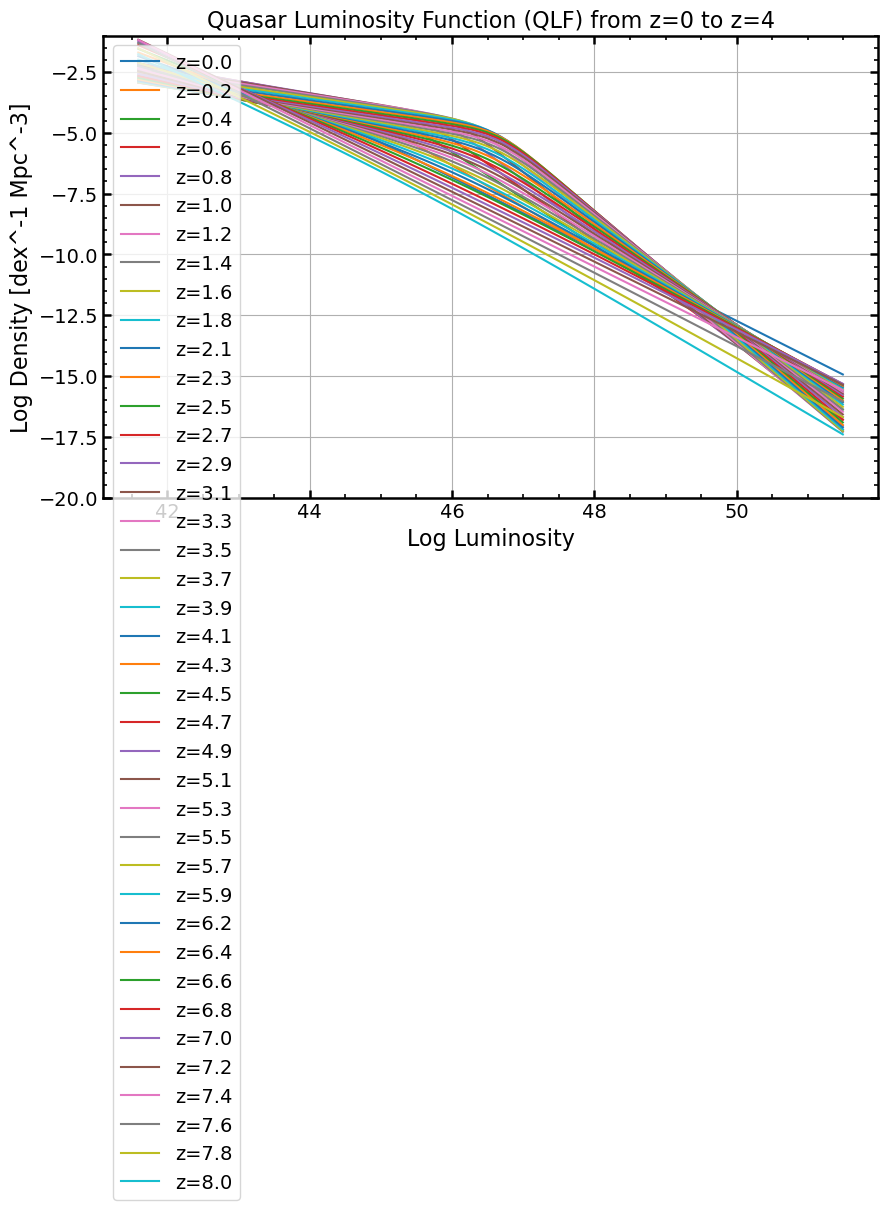

In [11]:
from utilities import return_bolometric_qlf

# Assuming the function to get the quasar LF is named `get_quasar_lf` in the utilities.py file

# Generate redshift values from 0 to 4
z_bins = np.linspace(0, 8, 40)
print(len(z_bins))

# Compute QLF for each redshift
qlf_values = [return_bolometric_qlf(redshift=z) for z in z_bins]
print(len(qlf_values))

# Extract luminosity and density values
luminosities = qlf_values[0][0]  # Luminosities are the same for all redshifts
M_grid = 90 - 2.5*luminosities # Mi(z=2)

# Extract densities for each redshift
phi_log10 = np.array([qlf[1] for qlf in qlf_values])


# Plot the QLF
plt.figure(figsize=(10, 6))
for i, z in enumerate(z_bins):  # Plot every 10th redshift for clarity
    plt.plot(luminosities, phi_log10[i], label=f'z={z:.1f}')
    #plt.plot(apparent_magnitudes, densities[i * 10], label=f'z={z:.1f} (apparent)')
plt.xlabel('Log Luminosity')
plt.ylabel('Log Density [dex^-1 Mpc^-3]')
plt.title('Quasar Luminosity Function (QLF) from z=0 to z=4')
plt.ylim(-20, -1)
plt.legend()
plt.grid()
plt.show()


In [12]:
import numpy as np
import astropy.units as u
from scipy.interpolate import RegularGridInterpolator

def mock_m_per_zbin(
    phi_log10,         # 2D array: either (len(z_bins)-1, len(M_grid)) at z-mids OR (len(z_bins), len(M_grid)) at edges
    M_grid,            # 1D array of absolute magnitudes (any order; will be sorted ascending)
    z_bins,            # 1D array of redshift bin edges
    area_deg2,         # survey area in deg^2
    alpha_nu,          # AB spectral index: f_nu ∝ nu^{alpha_nu}
    cosmo,             # astropy cosmology
    *,
    z_res=512,         # z sampling resolution for integrals/CDFs inside each bin
    m_scatter=0.0,     # optional Gaussian mag scatter
    kcorr_zref=None,   # if QLF is in Mi(zref), set e.g. kcorr_zref=2.0; otherwise None for same-filter K
    completeness=None, # optional callable C(m, z) -> [0,1] acceptance prob
    m_lim=None,        # optional magnitude limit (keep m < m_lim)
    rng=None
):
    """
    Returns
    -------
    per_z_m : list[np.ndarray]
        List of length len(z_bins)-1; each entry is the array of sampled apparent magnitudes in that z-bin.
    Nexp_per_bin : np.ndarray
        Expected counts per redshift bin (before completeness / m_lim).
    """
    rng = np.random.default_rng() if rng is None else rng

    # ---- prep grids & φ
    M = np.asarray(M_grid)
    order = np.argsort(M)         # ensure ascending M
    M = M[order]
    nM = len(M)

    z_bins = np.asarray(z_bins)
    z_mids = 0.5*(z_bins[:-1] + z_bins[1:])

    phi = np.asarray(phi_log10)
    # Orient φ so axis0 = z, axis1 = M
    if   phi.shape == (len(z_mids), len(M_grid)):
        z_support = z_mids
    elif phi.shape == (len(z_bins), len(M_grid)):
        z_support = z_bins
    elif phi.shape == (len(M_grid), len(z_mids)):
        phi = phi.T; z_support = z_mids
    elif phi.shape == (len(M_grid), len(z_bins)):
        phi = phi.T; z_support = z_bins
    else:
        raise ValueError("phi_log10 must be shaped either (len(z_bins)-1, len(M_grid)) or (len(z_bins), len(M_grid)), "
                         "optionally transposed.")

    # Reorder φ columns to match sorted M
    phi = phi[:, order]

    # Interpolator in (z, M) over log10 φ
    rgi = RegularGridInterpolator(
        (z_support, M), phi,
        method="linear", bounds_error=False, fill_value=-np.inf
    )

    # robust ΔM from edges
    edges = np.empty(nM+1)
    edges[1:-1] = 0.5*(M[1:] + M[:-1])
    edges[0]    = M[0]  - 0.5*(M[1]-M[0])
    edges[-1]   = M[-1] + 0.5*(M[-1]-M[-2])
    dM = np.diff(edges)

    area_sr = area_deg2 * (np.pi/180.0)**2
    per_z_m = []
    Nexp_per_bin = np.zeros(len(z_bins)-1)

    for i, (z1, z2) in enumerate(zip(z_bins[:-1], z_bins[1:])):
        # fine z-grid for this bin
        z = np.linspace(z1, z2, z_res)
        dVdz = cosmo.differential_comoving_volume(z).to_value(u.Mpc**3/u.sr) * area_sr

        # K-correction term
        if kcorr_zref is None:
            K = -2.5*(1.0 + alpha_nu)*np.log10(1.0 + z)
        else:
            K = -2.5*(1.0 + alpha_nu)*np.log10((1.0 + z)/(1.0 + kcorr_zref))

        DM = 5.0*np.log10(cosmo.luminosity_distance(z).to_value(u.pc)) - 5.0

        # φ_int(z) = ∫ φ(M,z) dM  (vectorized via RGI over the (z, M) grid)
        # Evaluate φ(M,z) on the rectangle z × M by flattening pairs, then reshape
        ZZ = np.repeat(z, nM)
        MM = np.tile(M, z.size)
        logphi_flat = rgi(np.column_stack([ZZ, MM]))
        phi_flat = np.where(np.isfinite(logphi_flat), 10.0**logphi_flat, 0.0)
        phi_zM = phi_flat.reshape(z.size, nM)
        phi_int_z = np.sum(phi_zM * dM[None, :], axis=1)  # integrate over M

        # Expected count in this z-bin:
        Nexp = np.trapz(phi_int_z * dVdz, z)
        Nexp_per_bin[i] = Nexp

        # Draw total N and sample z with weight ∝ φ_int(z) dV/dz
        N = rng.poisson(Nexp)
        if N == 0:
            per_z_m.append(np.empty(0, float))
            continue

        wz = phi_int_z * dVdz
        cdf_z = np.cumsum(wz)
        if cdf_z[-1] <= 0:
            per_z_m.append(np.empty(0, float))
            continue
        cdf_z /= cdf_z[-1]
        z_samp = np.interp(rng.random(N), cdf_z, z)

        # For all sampled z, sample M | z by inverse-CDF of φ(M,z)
        # Evaluate φ(M, z_samp) for all samples at once
        ZZs = np.repeat(z_samp, nM)
        MM  = np.tile(M, z_samp.size)
        logphi_flat = rgi(np.column_stack([ZZs, MM]))
        phi_flat = np.where(np.isfinite(logphi_flat), 10.0**logphi_flat, 0.0)
        phi_M_given_z = phi_flat.reshape(z_samp.size, nM)

        # Build per-object CDFs over M
        wM = phi_M_given_z * dM[None, :]
        rowsum = wM.sum(axis=1)
        valid = rowsum > 0
        # If some rows have zero weight, drop those draws (they contribute ~0 in expectation)
        if not np.all(valid):
            z_samp = z_samp[valid]
            wM = wM[valid]
            rowsum = rowsum[valid]
            if z_samp.size == 0:
                per_z_m.append(np.empty(0, float))
                continue

        cdfM = np.cumsum(wM, axis=1) / rowsum[:, None]
        _u = rng.random(z_samp.size)

        # find index where CDF crosses u
        idx = (cdfM < _u[:, None]).sum(axis=1)
        idx = np.clip(idx, 1, nM-1)
        cdf_lo = cdfM[np.arange(z_samp.size), idx-1]
        cdf_hi = cdfM[np.arange(z_samp.size), idx]
        M_lo   = M[idx-1]
        M_hi   = M[idx]
        t = (_u - cdf_lo) / (cdf_hi - cdf_lo + 1e-12)
        M_samp = M_lo + t*(M_hi - M_lo)

        # Map to observed-frame apparent magnitudes
        DM_s = 5.0*np.log10(cosmo.luminosity_distance(z_samp).to_value(u.pc)) - 5.0
        if kcorr_zref is None:
            K_s = -2.5*(1.0 + alpha_nu)*np.log10(1.0 + z_samp)
        else:
            K_s = -2.5*(1.0 + alpha_nu)*np.log10((1.0 + z_samp)/(1.0 + kcorr_zref))

        m_samp = M_samp + DM_s + K_s

        # Optional photometric scatter and selection
        if m_scatter > 0:
            m_samp = m_samp + rng.normal(0.0, m_scatter, size=m_samp.size)
        if m_lim is not None:
            keep = m_samp < m_lim
            m_samp = m_samp[keep]
            z_samp = z_samp[keep]
        if completeness is not None and m_samp.size > 0:
            p = np.clip(completeness(m_samp, z_samp), 0.0, 1.0)
            keep = rng.random(m_samp.size) < p
            m_samp = m_samp[keep]

        per_z_m.append(m_samp)
        print(f"Done sampling for z-bin {i+1}/{len(z_bins)-1} ({z1:.2f} to {z2:.2f}) with N={N}, ")

    return per_z_m, Nexp_per_bin


In [14]:
import numpy as np
import astropy.units as u
from scipy.interpolate import RegularGridInterpolator

def mock_m_per_zbin(
    phi_log10,         # 2D array: either (len(z_bins)-1, len(M_grid)) at z-mids OR (len(z_bins), len(M_grid)) at edges
    M_grid,            # 1D array of absolute magnitudes (any order; will be sorted ascending)
    z_bins,            # 1D array of redshift bin edges
    area_deg2,         # survey area in deg^2
    alpha_nu,          # AB spectral index: f_nu ∝ nu^{alpha_nu}
    cosmo,             # astropy cosmology
    *,
    z_res=512,         # z sampling resolution for integrals/CDFs inside each bin
    m_scatter=0.0,     # optional Gaussian mag scatter
    kcorr_zref=None,   # if QLF is in Mi(zref), set e.g. kcorr_zref=2.0; otherwise None for same-filter K
    completeness=None, # optional callable C(m, z) -> [0,1] acceptance prob
    m_lim=None,        # optional magnitude limit (keep m < m_lim)
    rng=None,
    # ---- new options (backward compatible) ----
    return_z=False,        # also return per-bin redshift samples and realized counts
    return_global=False,   # also return concatenated (z_all, m_all, bin_index)
    verbose=False,
):
    """
    Returns (by default, to preserve your original signature)
    --------------------------------
    per_z_m : list[np.ndarray]
        List of length len(z_bins)-1; each entry is the array of sampled apparent magnitudes
        (after scatter/selection) in that z-bin.
    Nexp_per_bin : np.ndarray
        Expected counts per redshift bin (before completeness / m_lim).

    If return_z is True, two more items are appended:
      per_z   : list[np.ndarray]  (sampled redshifts kept after selection, per bin)
      Nsel_per_bin : np.ndarray   (realized counts after selection per bin)

    If return_global is True as well, three more items are appended:
      z_all, m_all, bin_index : concatenated arrays of all selected objects and their bin indices.
    """
    rng = np.random.default_rng() if rng is None else rng

    # ---- prep grids & φ
    M = np.asarray(M_grid)
    order = np.argsort(M)         # ensure ascending M
    M = M[order]
    nM = len(M)

    z_bins = np.asarray(z_bins)
    z_mids = 0.5*(z_bins[:-1] + z_bins[1:])

    phi = np.asarray(phi_log10)
    # Orient φ so axis0 = z, axis1 = M
    if   phi.shape == (len(z_mids), len(M_grid)):
        z_support = z_mids
    elif phi.shape == (len(z_bins), len(M_grid)):
        z_support = z_bins
    elif phi.shape == (len(M_grid), len(z_mids)):
        phi = phi.T; z_support = z_mids
    elif phi.shape == (len(M_grid), len(z_bins)):
        phi = phi.T; z_support = z_bins
    else:
        raise ValueError("phi_log10 must be shaped either (len(z_bins)-1, len(M_grid)) or (len(z_bins), len(M_grid)), "
                         "optionally transposed.")

    # Reorder φ columns to match sorted M
    phi = phi[:, order]

    # Interpolator in (z, M) over log10 φ
    rgi = RegularGridInterpolator(
        (z_support, M), phi,
        method="linear", bounds_error=False, fill_value=-np.inf
    )

    # robust ΔM from edges
    edges = np.empty(nM+1)
    edges[1:-1] = 0.5*(M[1:] + M[:-1])
    edges[0]    = M[0]  - 0.5*(M[1]-M[0])
    edges[-1]   = M[-1] + 0.5*(M[-1]-M[-2])
    dM = np.diff(edges)

    area_sr = area_deg2 * (np.pi/180.0)**2
    per_z_m = []
    Nexp_per_bin = np.zeros(len(z_bins)-1)
    # new
    per_z = []
    Nsel_per_bin = np.zeros(len(z_bins)-1, dtype=int)

    for i, (z1, z2) in enumerate(zip(z_bins[:-1], z_bins[1:])):
        # fine z-grid for this bin
        z = np.linspace(z1, z2, z_res)
        dVdz = cosmo.differential_comoving_volume(z).to_value(u.Mpc**3/u.sr) * area_sr

        # K-correction term
        if kcorr_zref is None:
            K = -2.5*(1.0 + alpha_nu)*np.log10(1.0 + z)
        else:
            K = -2.5*(1.0 + alpha_nu)*np.log10((1.0 + z)/(1.0 + kcorr_zref))

        DM = 5.0*np.log10(cosmo.luminosity_distance(z).to_value(u.pc)) - 5.0

        # φ_int(z) = ∫ φ(M,z) dM
        ZZ = np.repeat(z, nM)
        MM = np.tile(M, z.size)
        logphi_flat = rgi(np.column_stack([ZZ, MM]))
        phi_flat = np.where(np.isfinite(logphi_flat), 10.0**logphi_flat, 0.0)
        phi_zM = phi_flat.reshape(z.size, nM)
        phi_int_z = np.sum(phi_zM * dM[None, :], axis=1)

        # Expected count in this z-bin (pre-selection):
        Nexp = np.trapz(phi_int_z * dVdz, z)
        Nexp_per_bin[i] = Nexp

        # Draw total N and sample z with weight ∝ φ_int(z) dV/dz
        N = rng.poisson(Nexp)
        if N == 0 or not np.isfinite(Nexp) or Nexp <= 0:
            per_z_m.append(np.empty(0, float))
            per_z.append(np.empty(0, float))
            if verbose:
                print(f"[bin {i+1}/{len(z_bins)-1}] z=({z1:.3f},{z2:.3f}) Nexp={Nexp:.2f} -> N=0")
            continue

        wz = phi_int_z * dVdz
        cdf_z = np.cumsum(wz)
        if cdf_z[-1] <= 0 or not np.isfinite(cdf_z[-1]):
            per_z_m.append(np.empty(0, float))
            per_z.append(np.empty(0, float))
            if verbose:
                print(f"[bin {i+1}/{len(z_bins)-1}] empty weight over z; skipping.")
            continue
        cdf_z /= cdf_z[-1]
        z_samp = np.interp(rng.random(N), cdf_z, z)

        # For all sampled z, sample M | z by inverse-CDF of φ(M,z)
        ZZs = np.repeat(z_samp, nM)
        MM  = np.tile(M, z_samp.size)
        logphi_flat = rgi(np.column_stack([ZZs, MM]))
        phi_flat = np.where(np.isfinite(logphi_flat), 10.0**logphi_flat, 0.0)
        phi_M_given_z = phi_flat.reshape(z_samp.size, nM)

        # Build per-object CDFs over M
        wM = phi_M_given_z * dM[None, :]
        rowsum = wM.sum(axis=1)
        valid = rowsum > 0
        if not np.all(valid):
            z_samp = z_samp[valid]
            wM = wM[valid]
            rowsum = rowsum[valid]
            if z_samp.size == 0:
                per_z_m.append(np.empty(0, float))
                per_z.append(np.empty(0, float))
                if verbose:
                    print(f"[bin {i+1}/{len(z_bins)-1}] no valid M|z draws; skipping.")
                continue

        cdfM = np.cumsum(wM, axis=1) / rowsum[:, None]
        _u = rng.random(z_samp.size)

        # find index where CDF crosses u
        idx = (cdfM < _u[:, None]).sum(axis=1)
        idx = np.clip(idx, 1, nM-1)
        cdf_lo = cdfM[np.arange(z_samp.size), idx-1]
        cdf_hi = cdfM[np.arange(z_samp.size), idx]
        M_lo   = M[idx-1]
        M_hi   = M[idx]
        # linear interpolation within the bin
        t = (_u - cdf_lo) / (cdf_hi - cdf_lo + 1e-12)
        M_samp = M_lo + t*(M_hi - M_lo)

        # Map to observed-frame apparent magnitudes
        DM_s = 5.0*np.log10(cosmo.luminosity_distance(z_samp).to_value(u.pc)) - 5.0
        if kcorr_zref is None:
            K_s = -2.5*(1.0 + alpha_nu)*np.log10(1.0 + z_samp)
        else:
            K_s = -2.5*(1.0 + alpha_nu)*np.log10((1.0 + z_samp)/(1.0 + kcorr_zref))

        m_samp = M_samp + DM_s + K_s

        # Optional photometric scatter and selection
        if m_scatter > 0:
            m_samp = m_samp + rng.normal(0.0, m_scatter, size=m_samp.size)

        if m_lim is not None and m_samp.size > 0:
            keep = m_samp < m_lim
            m_samp = m_samp[keep]
            z_samp = z_samp[keep]

        if completeness is not None and m_samp.size > 0:
            p = np.clip(completeness(m_samp, z_samp), 0.0, 1.0)
            keep = rng.random(m_samp.size) < p
            m_samp = m_samp[keep]
            z_samp = z_samp[keep]

        per_z_m.append(m_samp)
        per_z.append(z_samp)
        Nsel_per_bin[i] = m_samp.size

        if verbose:
            print(f"[bin {i+1}/{len(z_bins)-1}] z=({z1:.3f},{z2:.3f}) "
                  f"Nexp={Nexp:.1f} -> drew {N}, kept {m_samp.size}")

    # ---- returns (backward compatible by default) ----
    if not (return_z or return_global):
        return per_z_m, Nexp_per_bin

    # otherwise, append extras
    out = (per_z_m, Nexp_per_bin, per_z, Nsel_per_bin)
    if return_global:
        if any(len(v) for v in per_z_m):
            z_all = np.concatenate([z for z in per_z if z.size])
            m_all = np.concatenate([m for m in per_z_m if m.size])
            bin_index = np.concatenate([
                np.full(len(m), i, dtype=int) for i, m in enumerate(per_z_m) if len(m)
            ])
        else:
            z_all = np.empty(0, float); m_all = np.empty(0, float); bin_index = np.empty(0, int)
        out = out + (z_all, m_all, bin_index)
    return out


In [18]:
area_deg2 = 2.7
alpha_nu = -0.5  # spectral index
per_z_m, Nexp, per_z, Nsel, z_all, m_all, bin_idx = mock_m_per_zbin(phi_log10, M_grid, z_bins, area_deg2, alpha_nu, cosmo, return_z=True, return_global=True)

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_11823/632936464.py:99: RuntimeWarning: divide by zero encountered in log10
  DM = 5.0*np.log10(cosmo.luminosity_distance(z).to_value(u.pc)) - 5.0
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_11823/632936464.py:110: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Nexp = np.trapz(phi_int_z * dVdz, z)


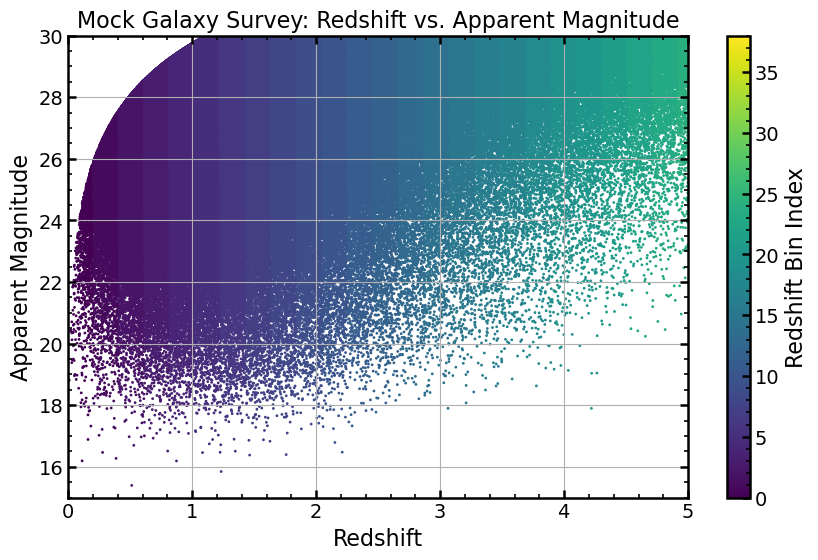

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(z_all, m_all, c=bin_idx, cmap='viridis', s=1)
plt.colorbar(label='Redshift Bin Index')
plt.xlabel('Redshift')
plt.ylabel('Apparent Magnitude')
plt.title('Mock Galaxy Survey: Redshift vs. Apparent Magnitude')
plt.xlim(0, 5)
plt.ylim(15, 30)
plt.grid()
plt.show()

Text(0.5, 0, 'm_samp')

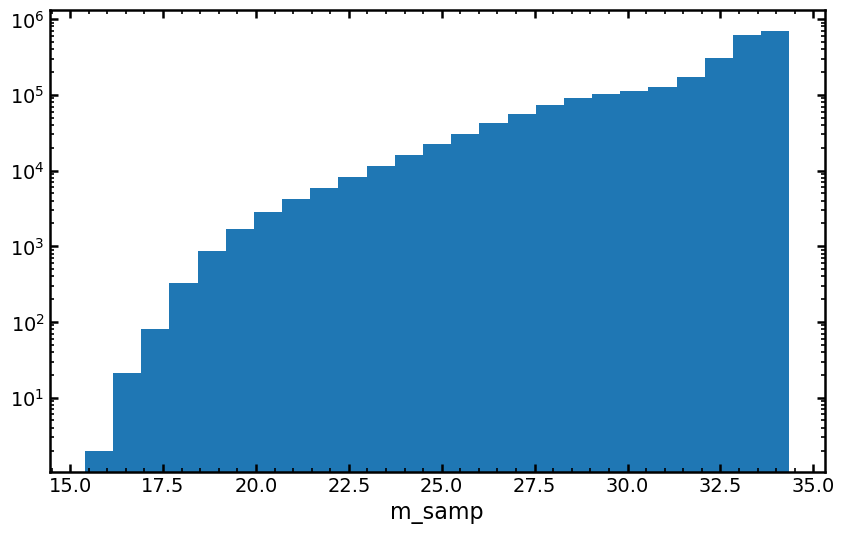

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(m_all, log=True, bins=25);
plt.xlabel('m_samp')

In [24]:
import h5py

with h5py.File('/Users/colinburke/research/isaque/eztaox/qvc/data/mock_mag_z.h5', 'w') as h5file:
    h5file.create_dataset('z', data=z_all)
    h5file.create_dataset('apparent_mag_i', data=m_all)